In [10]:
import pandas as pd
import numpy as np

Ue = 50e-3 # peak voltage

def calcBode(df):
    df['A'] = 20 * np.log10(df['Ua'] / Ue)
    df['phi'] = 360*df['f']*df['DeltaT']
    return df

df_I = calcBode(pd.read_csv("./data/BodeI.csv"))
df_NI = calcBode(pd.read_csv("./data/BodeNI.csv"))

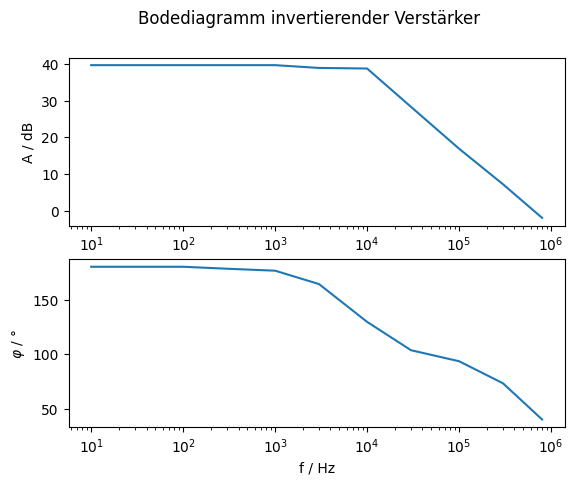

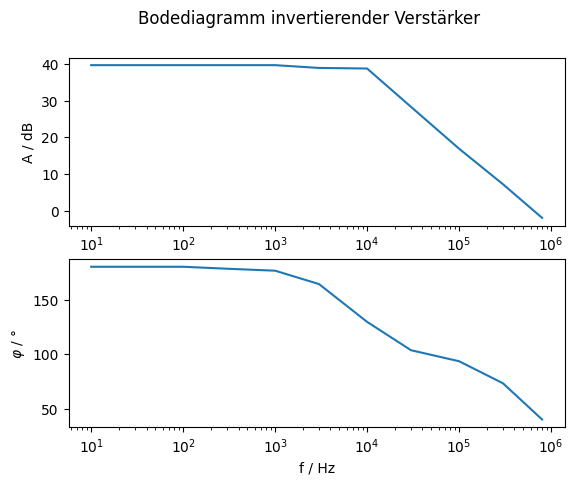

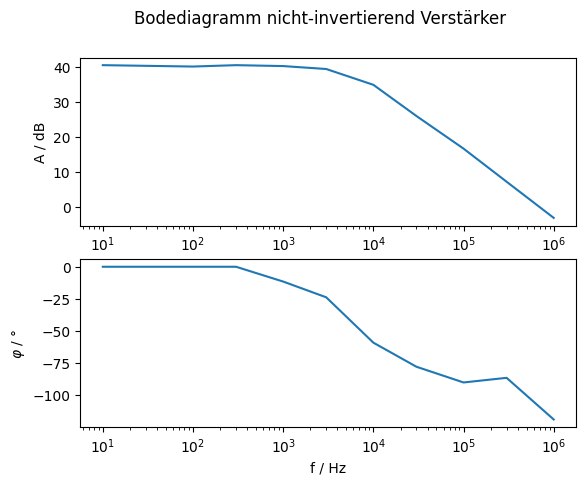

In [11]:
import matplotlib.pyplot as plt

def plot_bode(df):
    fig, (ax_abs, ax_arg) = plt.subplots(nrows=2, ncols=1)
    ax_abs.set_ylabel("A / dB")
    ax_abs.set_xscale('log')
    ax_abs.plot(df['f'], df['A'])

    ax_arg.set_xscale('log')
    ax_arg.set_xlabel("f / Hz")
    ax_arg.set_ylabel("$\\varphi$ / °")
    ax_arg.plot(df['f'], df['phi'])

    return fig

fig_I = plot_bode(df_I)
fig_I.suptitle('Bodediagramm invertierender Verstärker')
fig_I.savefig("./latex/images/bode_I.png")
fig_NI = plot_bode(df_NI)
fig_NI.suptitle('Bodediagramm nicht-invertierend Verstärker')
fig_NI.savefig("./latex/images/bode_NI.png")


In [22]:
fmt = {
    'f': '{:.0e}',
    'Ua': '{:.2f}',
    'DeltaT': '{:.2e}',
	'phi': '{:.2f}',
	'A': '{:.2f}',
}
latex_I = df_I.style.format(fmt).hide().to_latex()
latex_NI = df_NI.style.format(fmt).hide().to_latex()
with open("./latex/images/bode_I.tex", "w") as f:
    f.write(latex_I)
with open("./latex/images/bode_NI.tex", "w") as f:
    f.write(latex_NI)